# Migration discourse pilot - France 2018

In [1]:
import sys
from pathlib import Path

# Make the src package importable from the notebook
sys.path.insert(0, str(Path.cwd().parent))

import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import load, filters, typology, inspect, visualize
from src.config import PROCESSED_DIR, SOURCE_COUNTRY, SOURCE_YEAR

In [2]:
lf = load.load_facts_lazy()
load.inspect_schema(lf)

=== Schema ===
  entity_word_id: String
  speech_id: String
  paragraph_id: String
  sentence_id: String
  sentence_content_current: String
  sentence_content_previous: String
  sentence_content_next: String
  sentence_sentiment_value: Float32
  sentence_sentiment_ana: String
  total_tokens_in_speech: Int32
  total_tokens_in_session: Int32
  entity_category: String
  entity_content: String
  country: String
  session_date: Date
  debate_topic: String
  speaker_id: String
  speaker_ana: String

Total rows: 321,404


In [3]:
inspect.show_topic_distribution(lf, top_n=15)

debate_topic,n
str,u32
"""other""",80111
"""macro""",28709
"""mixed""",21182
"""inter""",19400
"""gover""",17159
…,…
"""trans""",12553
"""healt""",11254
"""domes""",10594


In [4]:
mentions = filters.build_migration_mentions(lf)
print(f"Foreign country mentions in {SOURCE_COUNTRY} {SOURCE_YEAR} migration debates: "
      f"{mentions.height:,}")
mentions.head(10)

Foreign country mentions in FRA 2018 migration debates: 1,493


sentence_id,speech_id,session_date,speaker_id,speaker_ana,entity_content,geo_class,context_window,sentence_content_current,sentence_sentiment_value,sentence_sentiment_ana,debate_topic,country
str,str,date,str,str,str,str,str,str,f32,str,str,str
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""Croisilles""","""foreign""","""I associate my colleagues from…","""The arrival of the President o…",4.765,"""senti:pospos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""United Kingdom""","""foreign""","""As the President of the Republ…","""Respect for the rule of law , …",3.72,"""senti:mixpos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""Calais Lande""","""foreign""","""Humanity and dignity , finally…","""How can one think that their o…",0.074,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA227076""","""regular""","""London""","""foreign""","""Finally , international action…","""The President of the Republic …",2.991,"""senti:neupos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA227076""","""regular""","""United Kingdom""","""foreign""","""Finally , international action…","""The President of the Republic …",2.991,"""senti:neupos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""",""" || Madam President , Minister…","""Madam President , Minister of …",1.212,"""senti:mixneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""","""As a result , the European Uni…","""Last November , you remember ,…",0.42,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""","""It is easy to say that we want…","""But it is even easier to send …",0.179,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1114.…","""ParlaMint-FR_2018-01-17-O1114.…",2018-01-17,"""PA608172""","""regular""","""Libya""","""foreign""","""But it is even easier to send …","""Courage and responsibility sho…",0.111,"""senti:negneg""","""immig""","""FRA"""


In [5]:
top = inspect.show_top_countries(mentions, top_n=20)
top

entity_content,n_mentions,geo_class,avg_sentiment,std_sentiment,min_sentiment,max_sentiment
str,u32,str,f32,f32,f32,f32
"""Mayotte""",211,"""french_overseas""",1.239,1.438,-0.111,5.075
"""United Kingdom""",84,"""foreign""",1.51,1.37,0.05,4.773
"""Italy""",76,"""foreign""",1.252,1.197,-0.077,4.817
"""Germany""",66,"""foreign""",1.499,1.264,0.07,4.835
"""Comoros""",63,"""foreign""",2.284,1.533,-0.027,4.975
…,…,…,…,…,…,…
"""Turkey""",16,"""foreign""",1.106,1.217,0.081,3.979
"""Syria""",12,"""foreign""",0.788,0.92,0.038,2.807
"""Lebanon""",12,"""foreign""",2.062,1.167,0.073,3.305


In [6]:
annotated = typology.apply_typology(mentions)
annotated.select(["entity_content", "ref_type", "sentiment_bucket",
                  "sentence_sentiment_value"]).head(10)

entity_content,ref_type,sentiment_bucket,sentence_sentiment_value
str,str,str,f32
"""Croisilles""","""mixed""","""positive""",4.765
"""United Kingdom""","""policy""","""positive""",3.72
"""Calais Lande""","""situation""","""negative""",0.074
"""London""","""policy""","""neutral""",2.991
"""United Kingdom""","""policy""","""neutral""",2.991
"""Libya""","""mixed""","""negative""",1.212
"""Libya""","""mixed""","""negative""",0.42
"""Libya""","""situation""","""negative""",0.179
"""Libya""","""situation""","""negative""",0.111


In [7]:
matrix = typology.build_2x3_matrix(annotated)
matrix

ref_type,negative,positive,neutral
str,u32,u32,u32
"""mixed""",214,50,73
"""situation""",220,43,106
"""neutral_reference""",86,12,61
"""policy""",338,53,237


In [8]:
top_5_countries = top.head(5)["entity_content"].to_list()
country_matrix = typology.matrix_by_country(
    annotated.filter(pl.col("entity_content").is_in(top_5_countries)),
    min_mentions=3,
)
country_matrix

entity_content,ref_type,sentiment_bucket,n
str,str,str,u32
"""Comoros""","""mixed""","""negative""",6
"""Comoros""","""mixed""","""neutral""",3
"""Comoros""","""mixed""","""positive""",7
"""Comoros""","""neutral_reference""","""negative""",4
"""Comoros""","""neutral_reference""","""neutral""",9
…,…,…,…
"""United Kingdom""","""policy""","""neutral""",17
"""United Kingdom""","""policy""","""positive""",4
"""United Kingdom""","""situation""","""negative""",9


In [9]:
# Look at Germany mentions - read 5 random ones and check whether the
# heuristic classification matches your reading
inspect.show_sample_contexts(annotated, country="Germany", n_samples=5)

session_date,entity_content,ref_type,sentiment_bucket,sentence_sentiment_value,context_window
date,str,str,str,f32,str
2018-04-21,"""Germany""","""policy""","""neutral""",2.877,"""The Minister of State said tha…"
2018-04-17,"""Germany""","""neutral_reference""","""positive""",4.835,"""Tunisia , without a doubt ; Le…"
2018-08-01,"""Germany""","""policy""","""negative""",0.323,"""So imagine some cases , absurd…"
2018-04-21,"""Germany""","""mixed""","""negative""",0.587,"""Indeed , the maximum length of…"
2018-04-21,"""Germany""","""situation""","""positive""",4.157,"""This amendment , tabled by my …"


In [10]:
inspect.show_sample_contexts(annotated, country="Italy", n_samples=5)

session_date,entity_content,ref_type,sentiment_bucket,sentence_sentiment_value,context_window
date,str,str,str,f32,str
2018-07-19,"""Italy""","""situation""","""neutral""",2.194,"""The Constitutional Council too…"
2018-04-17,"""Italy""","""policy""","""negative""",0.366,"""Malik Nurulain , says Nour , a…"
2018-11-06,"""Italy""","""policy""","""neutral""",3.042,"""Otherwise , it would be right …"
2018-06-13,"""Italy""","""mixed""","""negative""",1.474,"""We are also present , together…"
2018-07-25,"""Italy""","""policy""","""positive""",4.817,"""But what is this populist lepr…"


In [11]:
inspect.show_sample_contexts(annotated, country="Hungary", n_samples=5)

session_date,entity_content,ref_type,sentiment_bucket,sentence_sentiment_value,context_window
date,str,str,str,f32,str
2018-04-19,"""Hungary""","""policy""","""neutral""",2.471,"""What is considered a crime in …"
2018-04-10,"""Hungary""","""situation""","""neutral""",3.411,""" || Last Sunday , Mr Latomb , …"
2018-08-01,"""Hungary""","""policy""","""negative""",0.137,"""Another liberticide effect of …"
2018-04-19,"""Hungary""","""policy""","""negative""",0.763,"""Let us look , for example , at…"
2018-08-01,"""Hungary""","""policy""","""negative""",0.008,"""If he refuses , he may be subj…"


In [12]:
out_path = PROCESSED_DIR / f"{SOURCE_COUNTRY}_{SOURCE_YEAR}_migration_mentions.parquet"
annotated.write_parquet(out_path)
print(f"Saved {annotated.height:,} rows to {out_path}")

Saved 1,493 rows to /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2018_migration_mentions.parquet


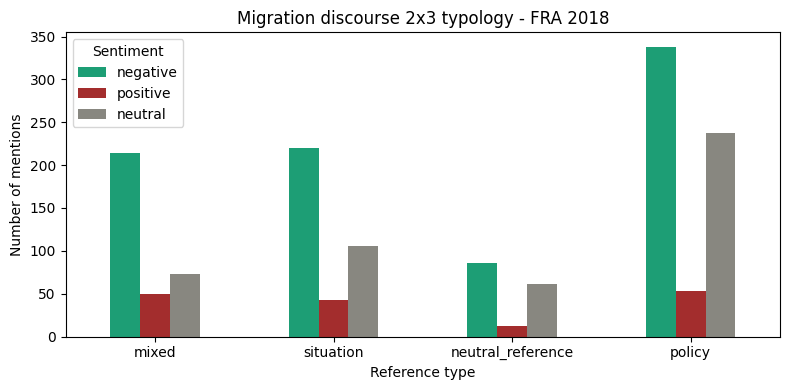

In [13]:
matrix_pd = matrix.to_pandas().set_index("ref_type")

fig, ax = plt.subplots(figsize=(8, 4))
matrix_pd.plot(kind="bar", stacked=False, ax=ax,
               color=["#1d9e75", "#a32d2d", "#888780"])
ax.set_title(f"Migration discourse 2x3 typology - {SOURCE_COUNTRY} {SOURCE_YEAR}")
ax.set_xlabel("Reference type")
ax.set_ylabel("Number of mentions")
ax.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Sentiment and geography interpretation

Sentiment colors use the ParlaMint categorical field `sentence_sentiment_ana`, not a zero-centered numeric threshold. `senti:negneg` and `senti:mixneg` are shown as negative; `senti:neuneg` and `senti:neupos` are shown as neutral; `senti:mixpos` and `senti:pospos` are shown as positive. The numeric `sentence_sentiment_value` is kept for inspection, but in this parquet it is not centered at zero.

Mayotte, French Guiana, and other French overseas territories are kept because they matter in migration debates. They are marked as `geo_class = french_overseas`, so they should not be read as foreign states.

## explanation for the visualizations

**What is counted.**  start from rows in the facts table where `debate_topic == "immig"`, meaning the debate is classified as migration/immigration. We then keep only named entities with `entity_category == "LOC"`

**French overseas territories.** Mayotte, French Guiana, and similar entities remain in the dataset because they are central in French migration debates, but they are explicitly marked as `geo_class = french_overseas`. They are not foreign states. In charts they are labelled with `(French overseas)` and shown in a separate color when geography is the main dimension.

**Policy vs situation references.** `policy` means the context window contains institutional or legal markers such as law, policy, government, quota, asylum, visa, agreement, model, or system. `situation` means the context window contains event/context markers such as crisis, arrivals, border, camp, refugees, migrants, war, conflict, deaths, or Mediterranean. `mixed` means both policy and situation evidence are present; `neutral_reference` means neither marker family is found. This is a transparent pilot heuristic for manual validation.

**Positive / negative / neutral.** Sentiment colors use ParlaMint's categorical field `sentence_sentiment_ana`: `senti:negneg` and `senti:mixneg` are negative; `senti:neuneg` and `senti:neupos` are neutral; `senti:mixpos` and `senti:pospos` are positive. We do not use a zero threshold on `sentence_sentiment_value`, because in this parquet the numeric scale is not centered at zero.

## Distribution of mentioned entities

We show two distribution views: first, the 10 most mentioned countries/cases; second, all entities with at least 50 mentions. Entities with fewer than 50 mentions are not shown in the main visualizations, because the chart becomes too noisy. A full audit CSV is still saved locally so the filtering decision remains transparent.

In [14]:
# Explanation: Show the entities used in the "everything" visualization.
# Explanation: We keep only entities with at least 50 mentions in the displayed table/chart.
with pl.Config(tbl_rows=100, tbl_cols=8, fmt_str_lengths=80):
    significant_entity_distribution = inspect.country_distribution(annotated, min_mentions=50)
    display(significant_entity_distribution)


entity_content,geo_class,n_mentions,share_percent
str,str,u32,f64
"""Mayotte""","""french_overseas""",211,14.13
"""United Kingdom""","""foreign""",84,5.63
"""Italy""","""foreign""",76,5.09
"""Germany""","""foreign""",66,4.42
"""Comoros""","""foreign""",63,4.22


## Country visualizations

These figures show how foreign countries and French overseas territories are mentioned in French migration debates. Colors are stable across charts: green = positive, red = negative, gray = neutral. For reference type, policy means institutional or legislative comparison; situation means international context or events.

In [15]:
# Explanation: Save top-10 visualizations and an "all significant entities" view.
# Explanation: "All significant" means all entities with at least 50 mentions.
figure_paths = visualize.save_all_figures(
    annotated,
    processed_dir=PROCESSED_DIR,
    top_n=10,
    min_mentions_for_all=50,
)

# Explanation: Printing the paths makes it easy for colleagues to find the files.
figure_paths


{'entity_distribution_top10': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/entity_distribution_top10.png'),
 'entity_distribution_min50': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/entity_distribution_min50.png'),
 'entity_distribution_min50_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_min50.csv'),
 'entity_distribution_all_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_all_for_audit.csv'),
 'country_sentiment': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/country_sentiment_mentions_top10.png'),
 'country_referenc

entity_distribution_top10: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/entity_distribution_top10.png


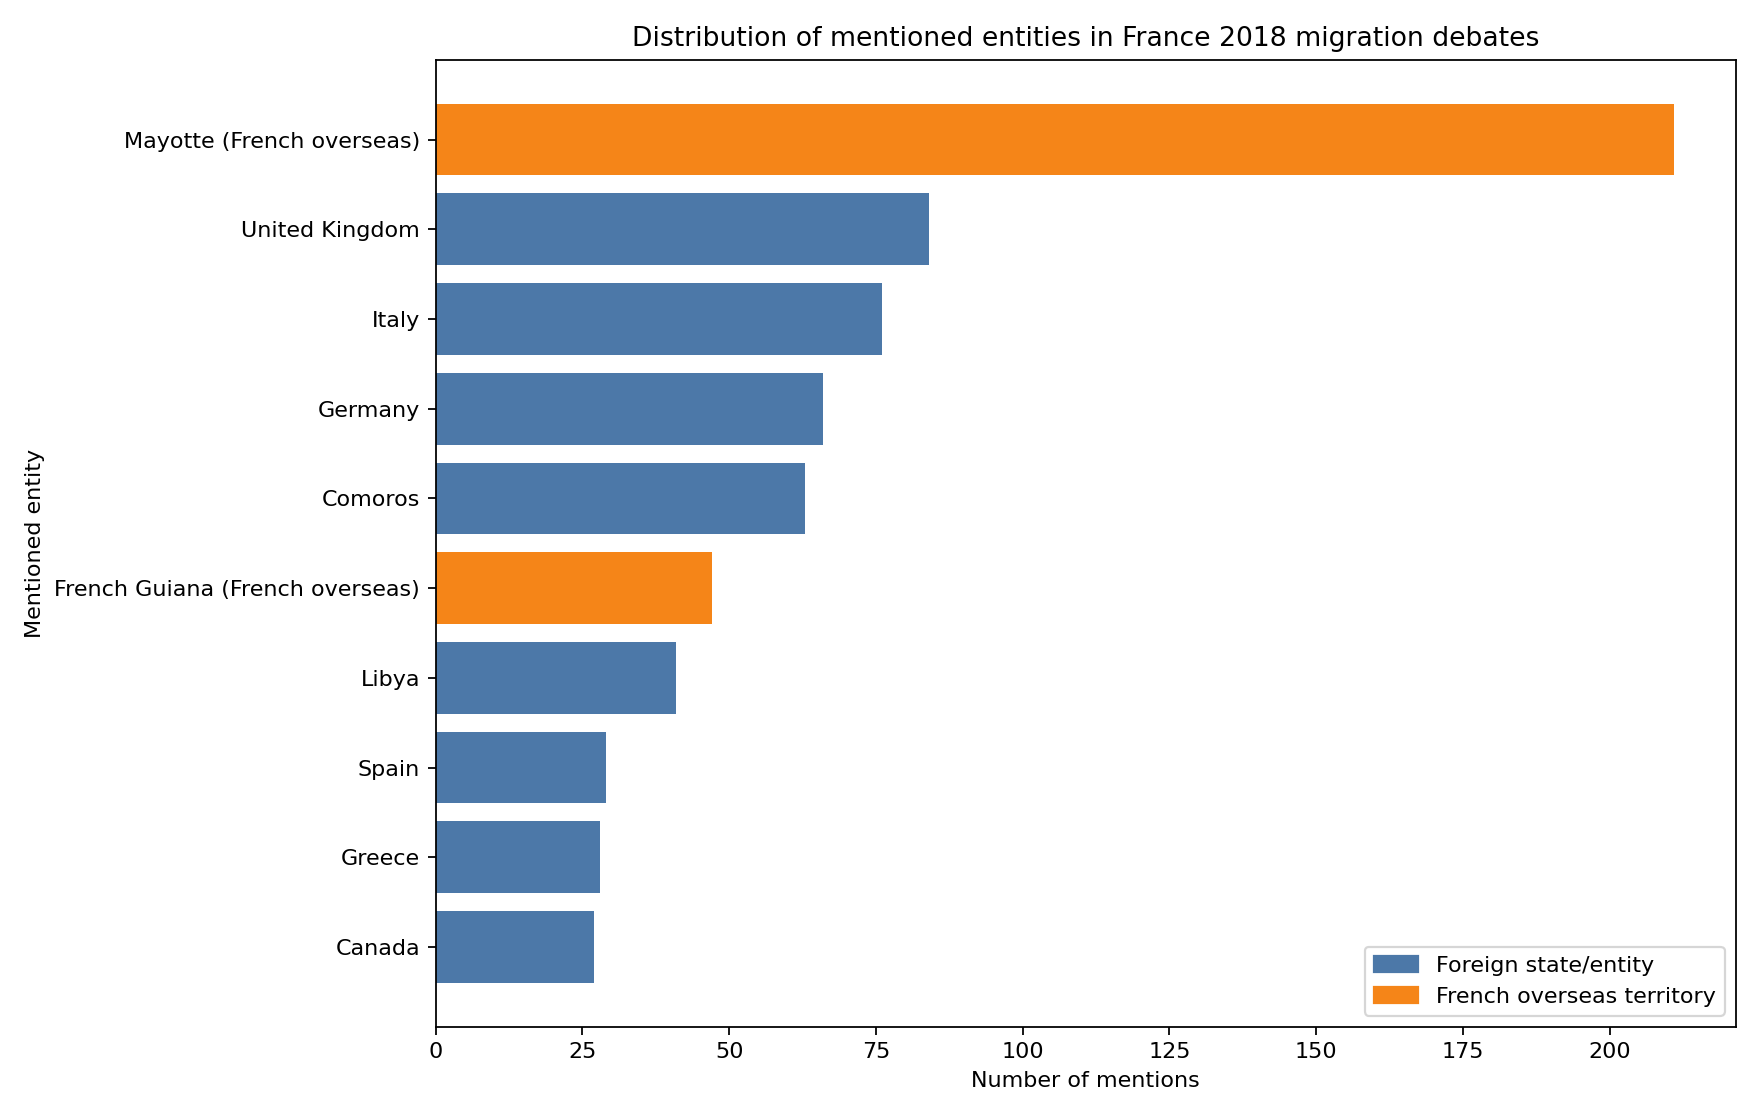

entity_distribution_min50: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/entity_distribution_min50.png


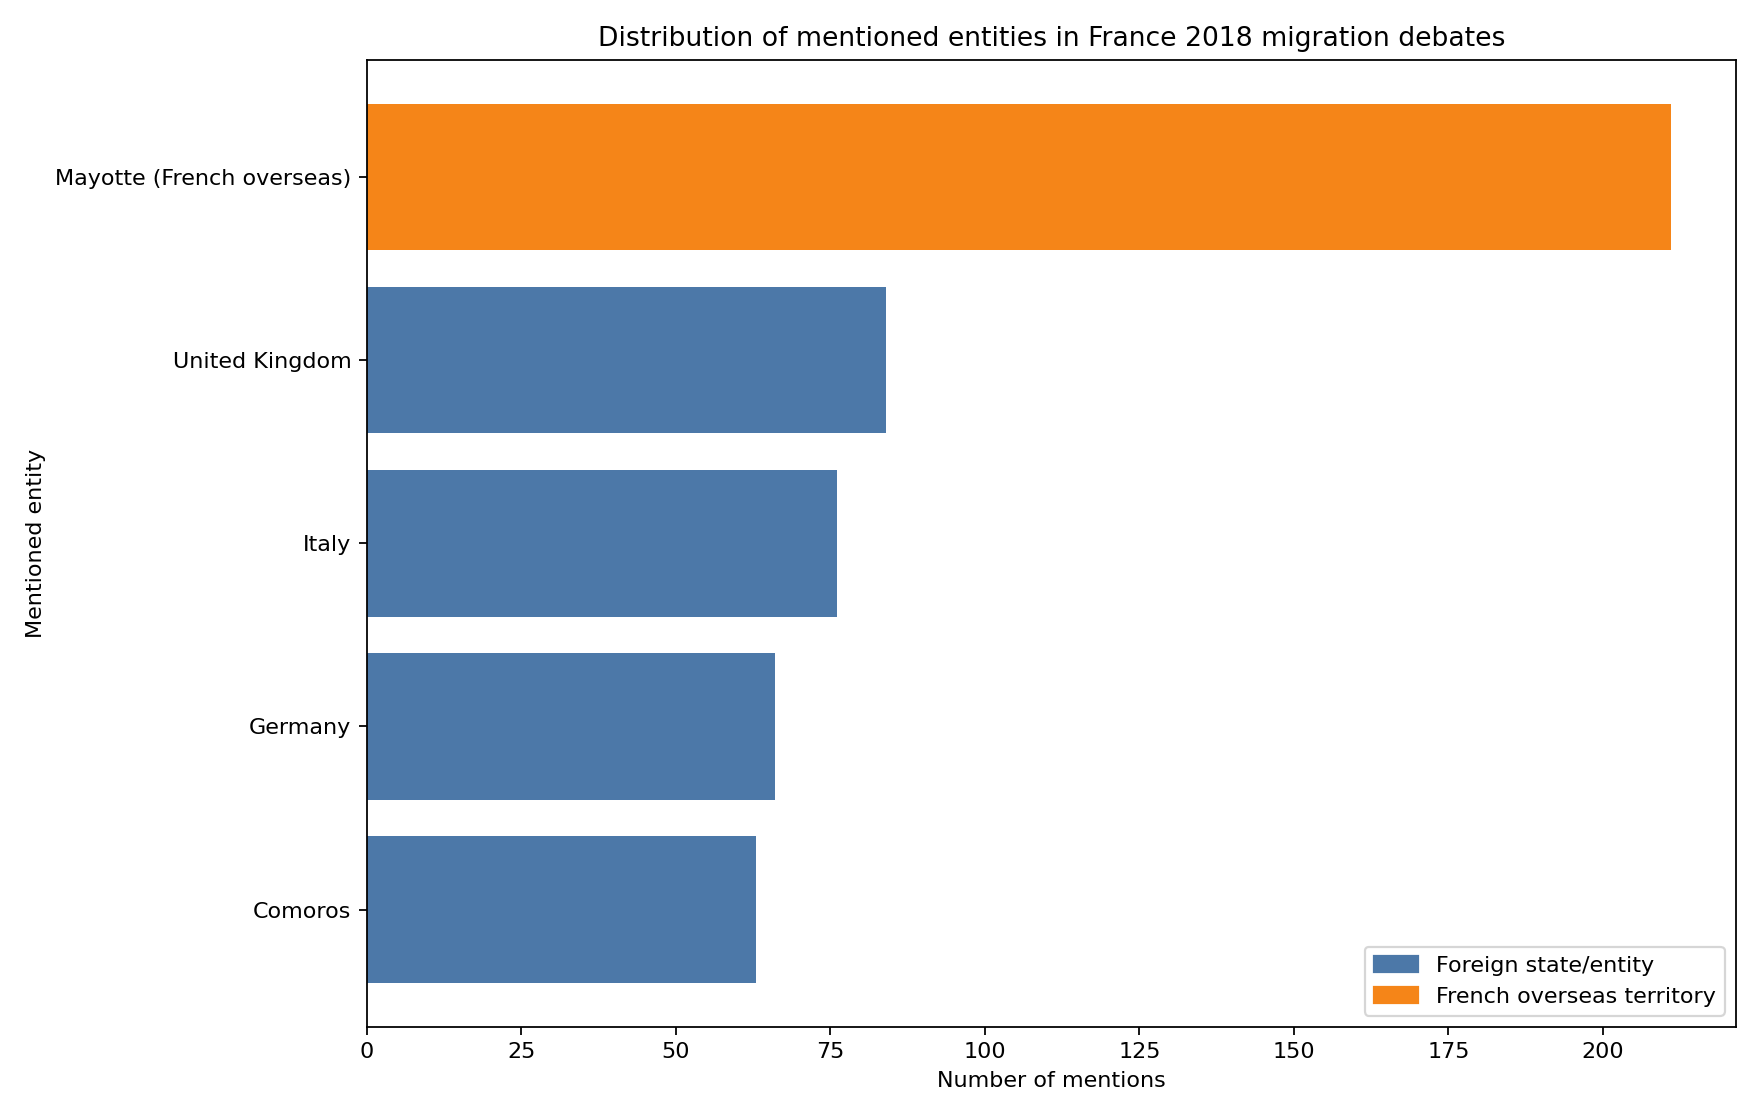

entity_distribution_min50_csv: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_min50.csv
entity_distribution_all_csv: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/entity_distribution_all_for_audit.csv
country_sentiment: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/country_sentiment_mentions_top10.png


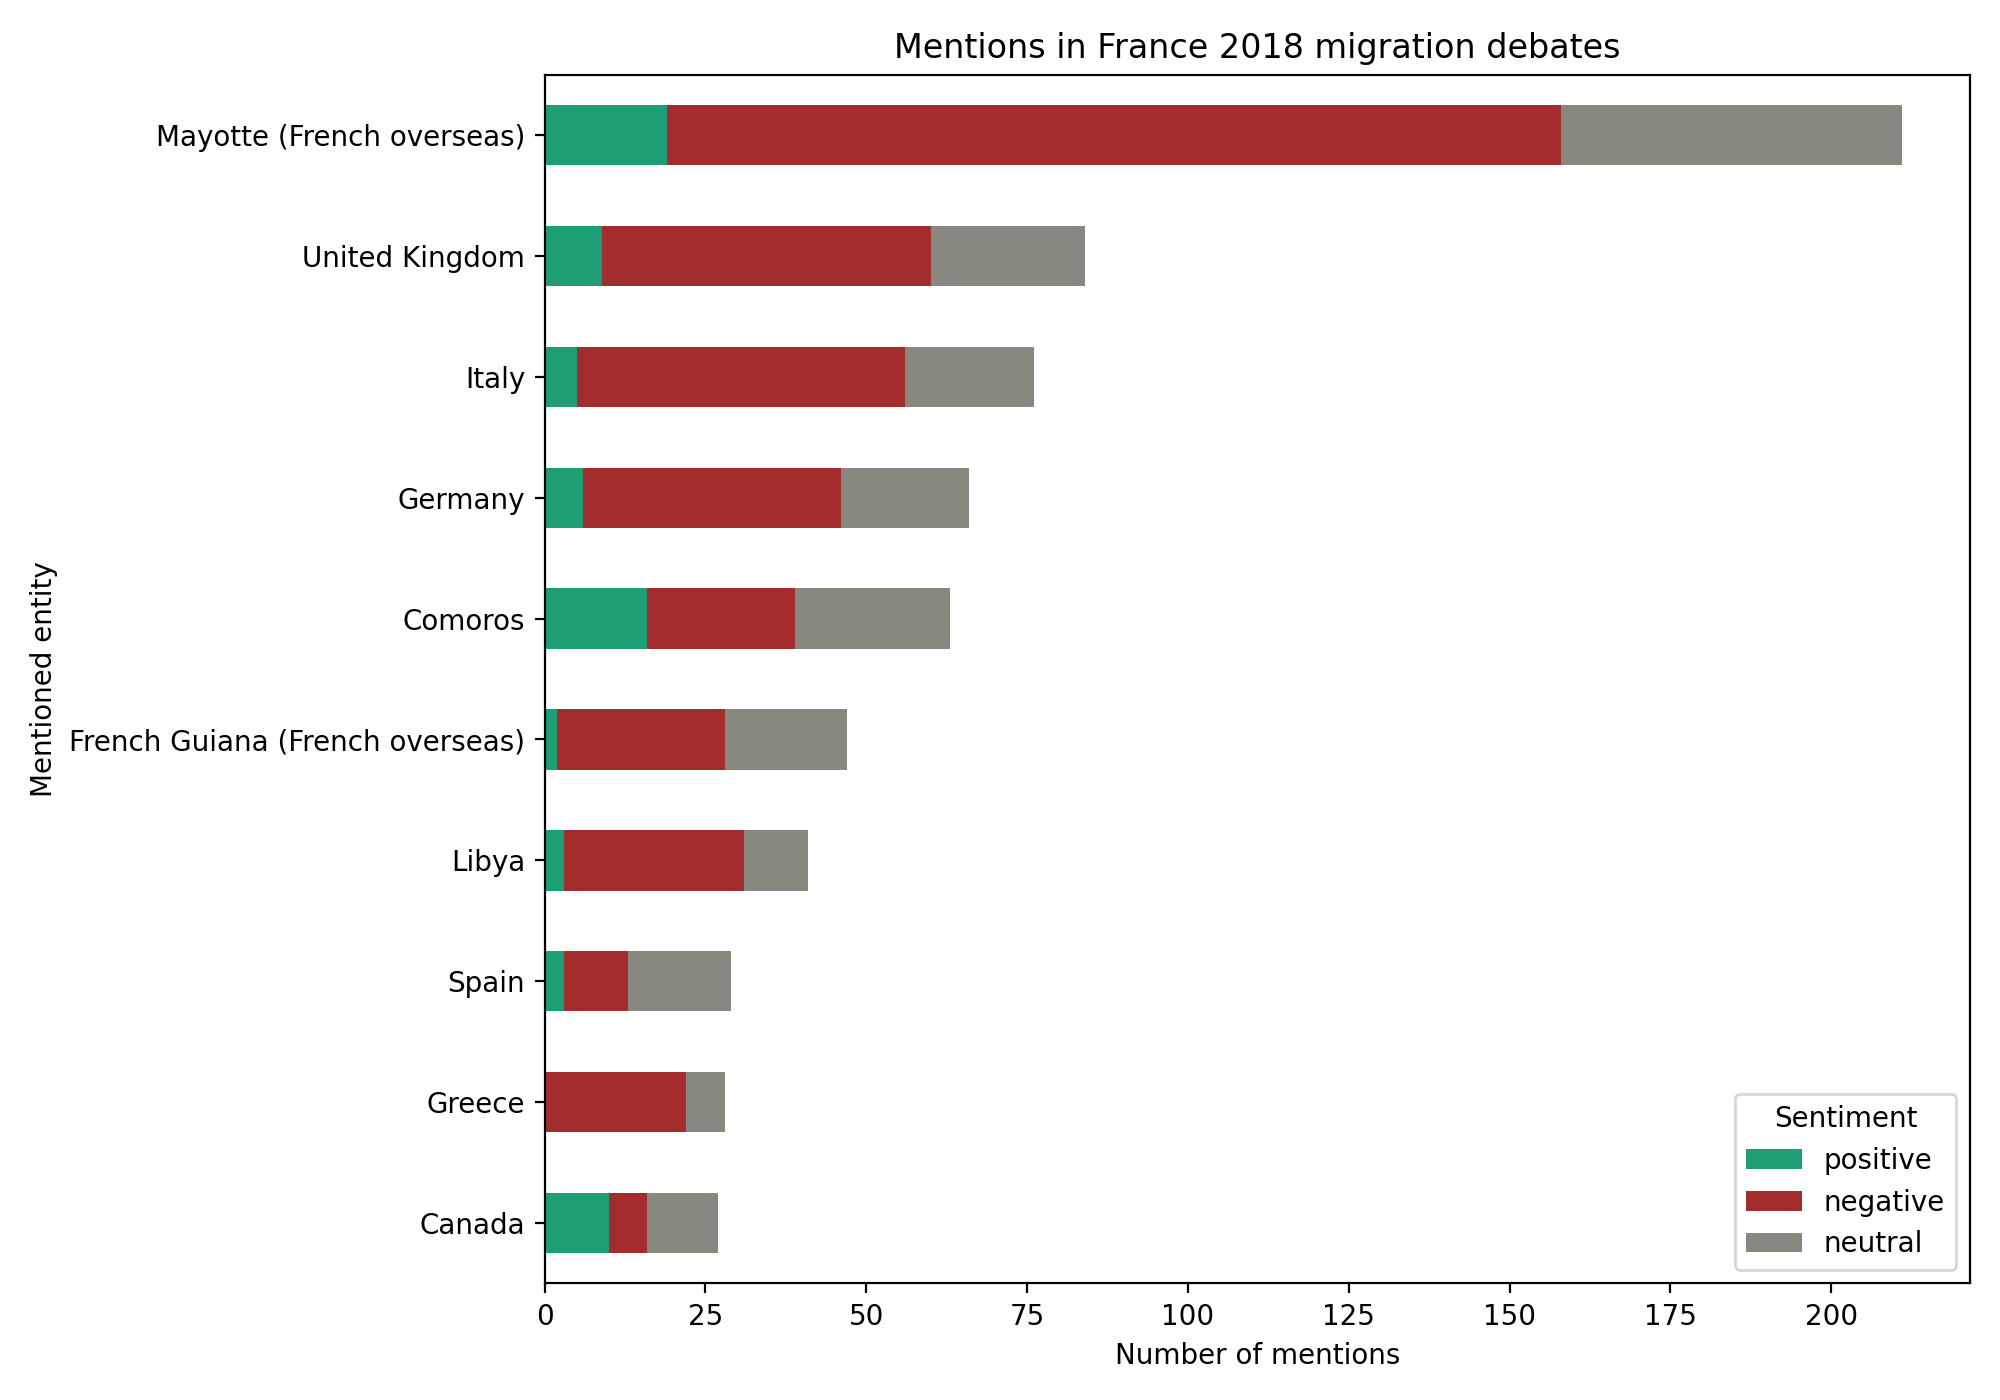

country_reference_type: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/country_reference_type_mentions_top10.png


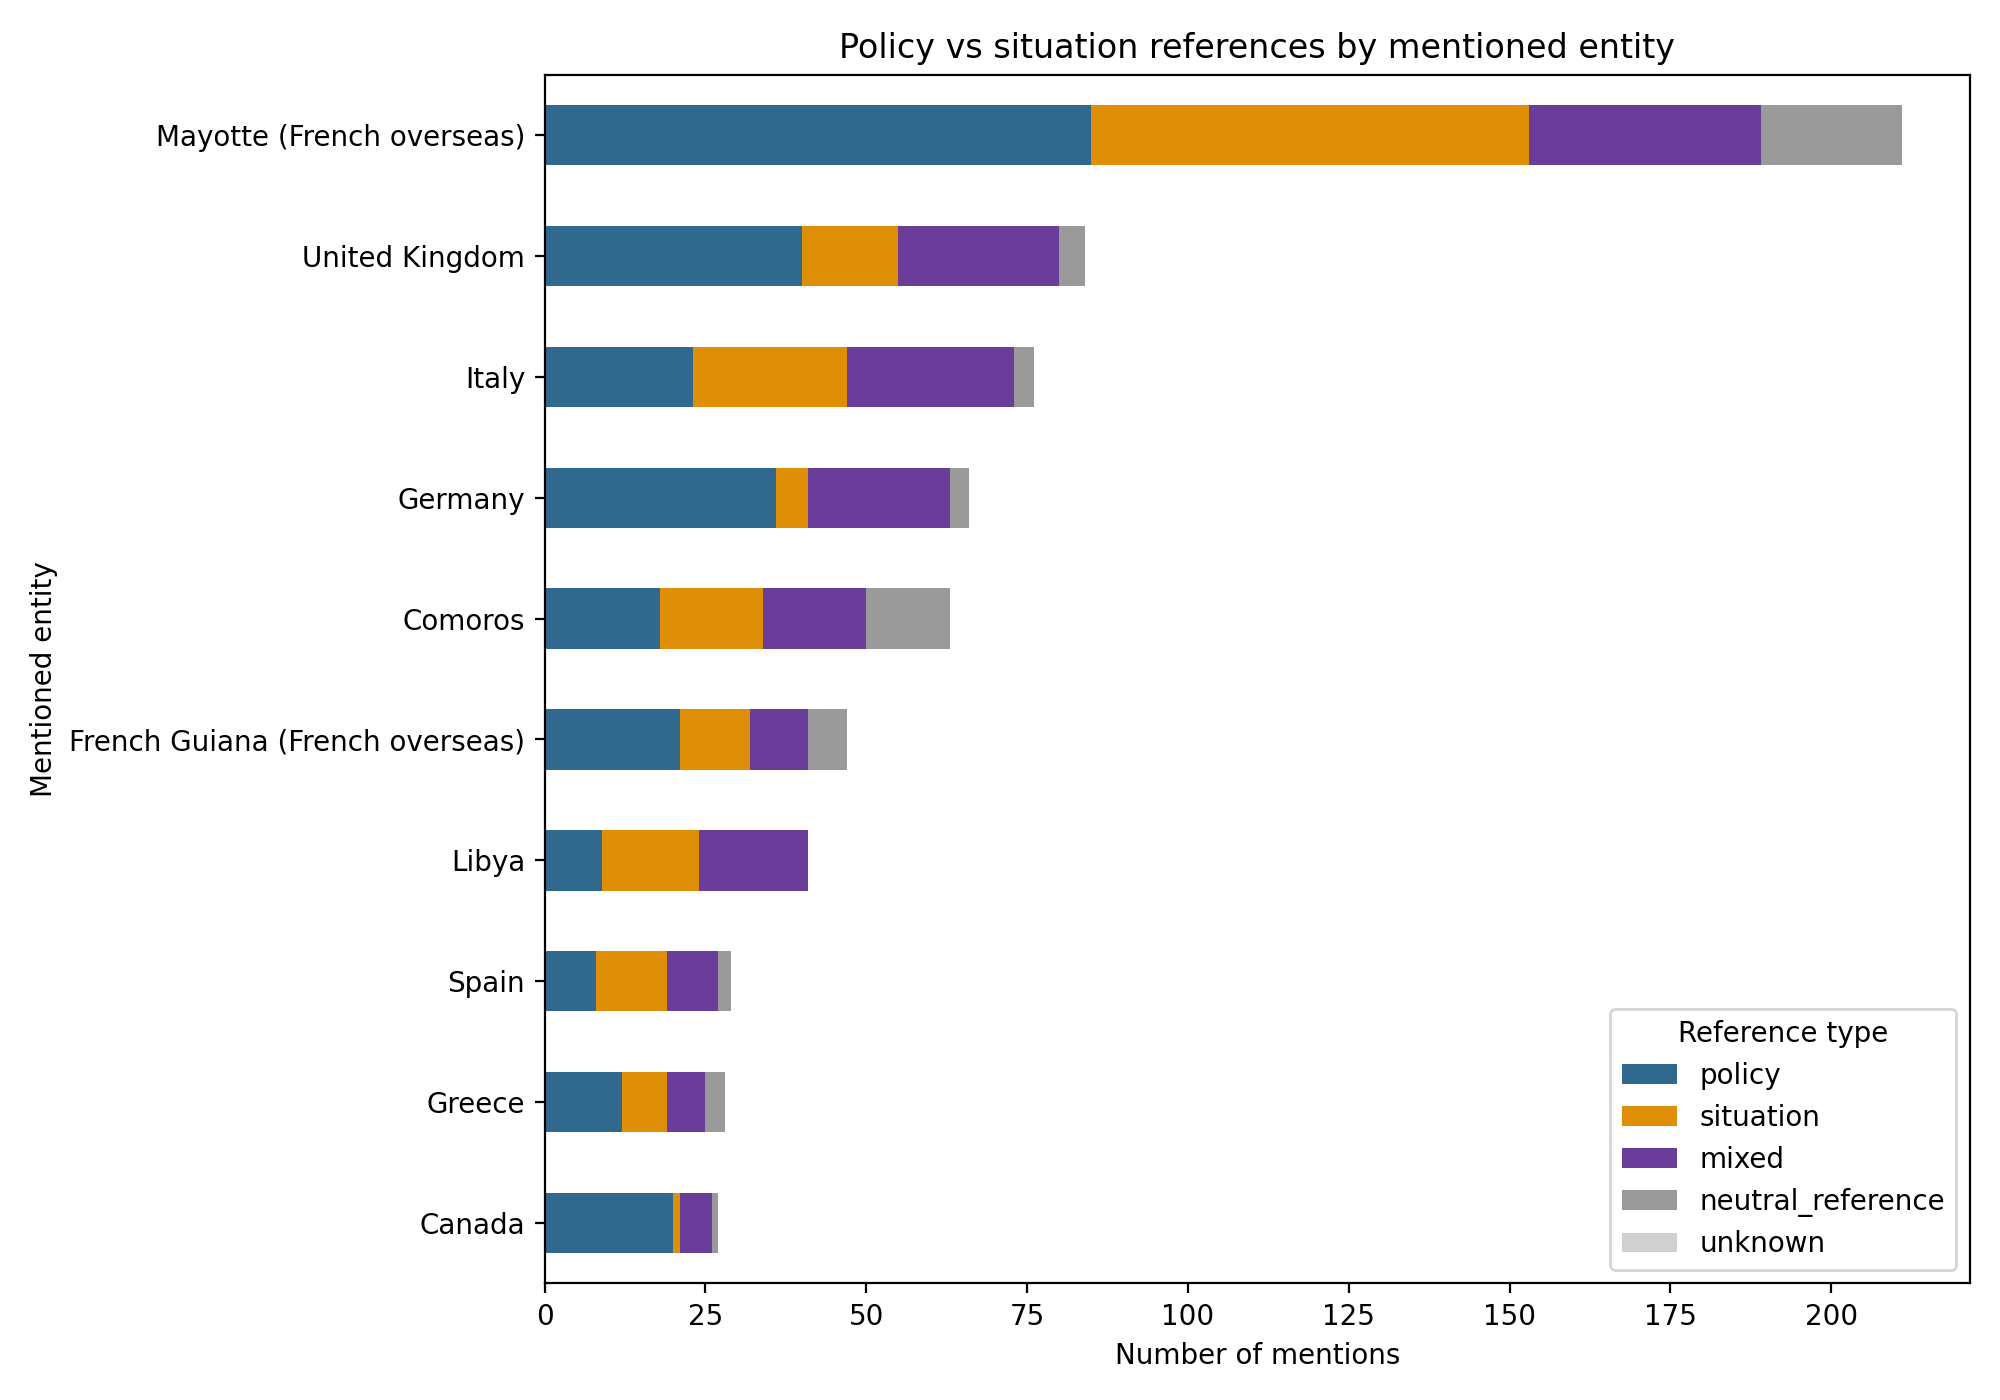

policy_vs_situation_sentiment: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/policy_vs_situation_sentiment_top10.png


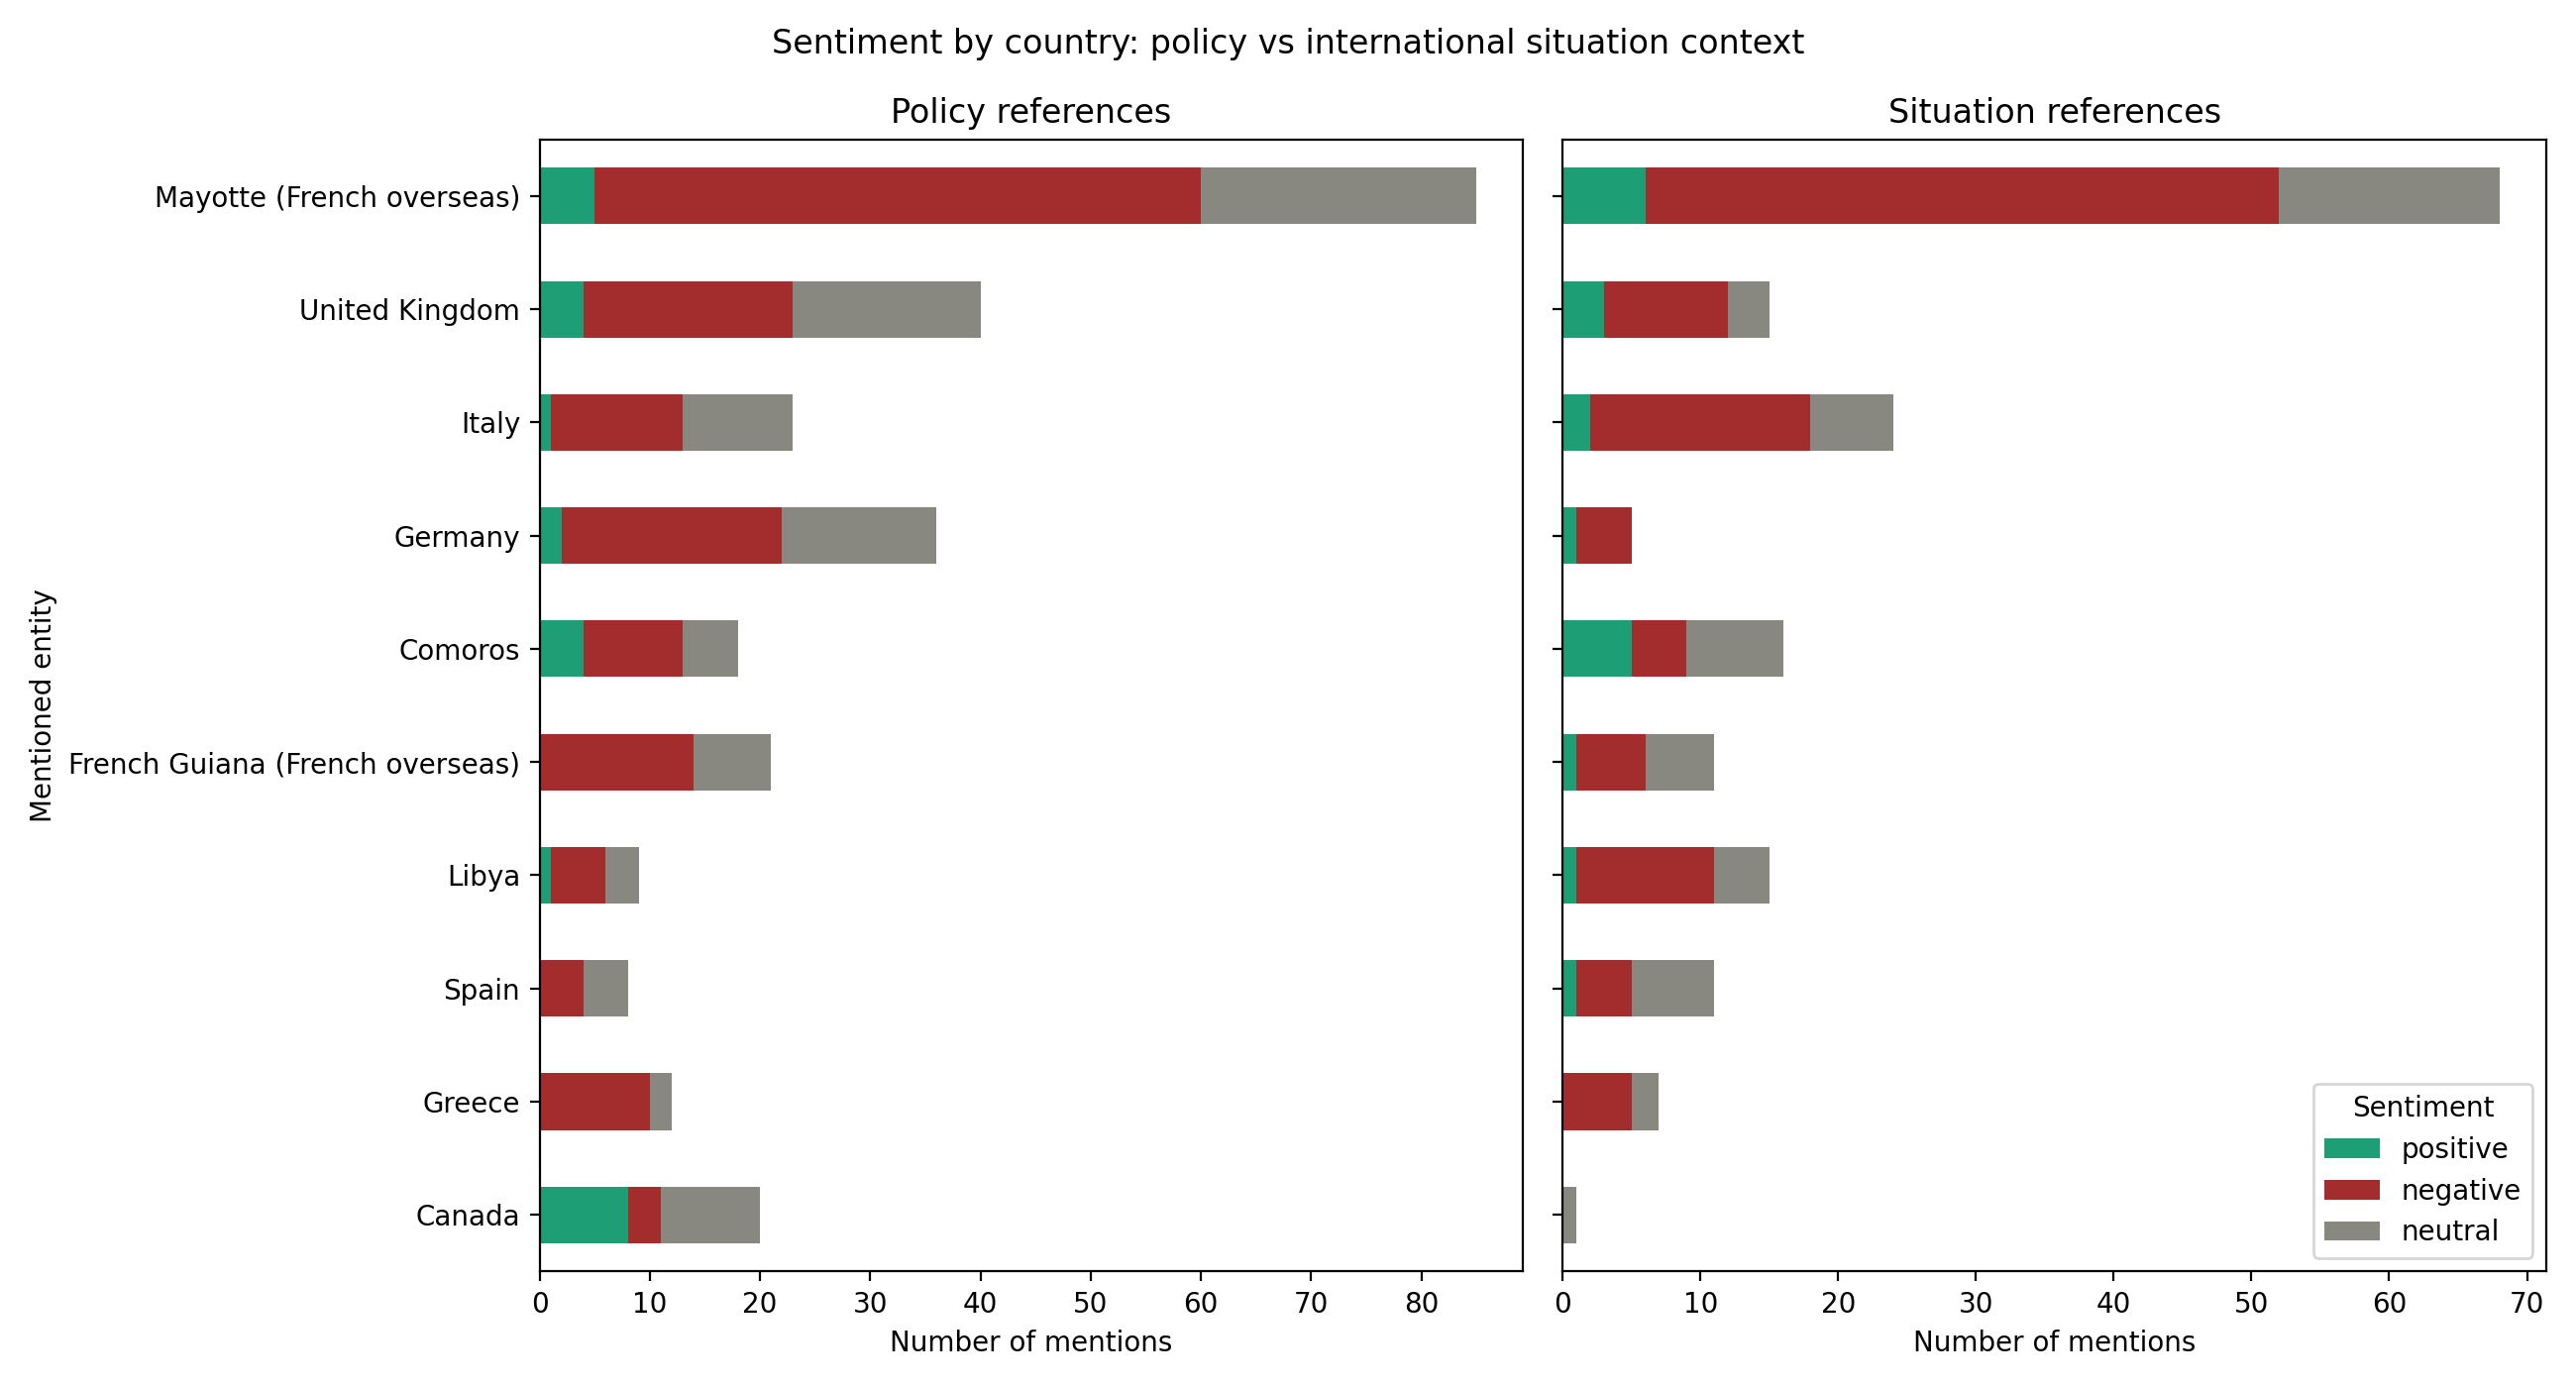

reference_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures/country_reference_heatmap_top10.png


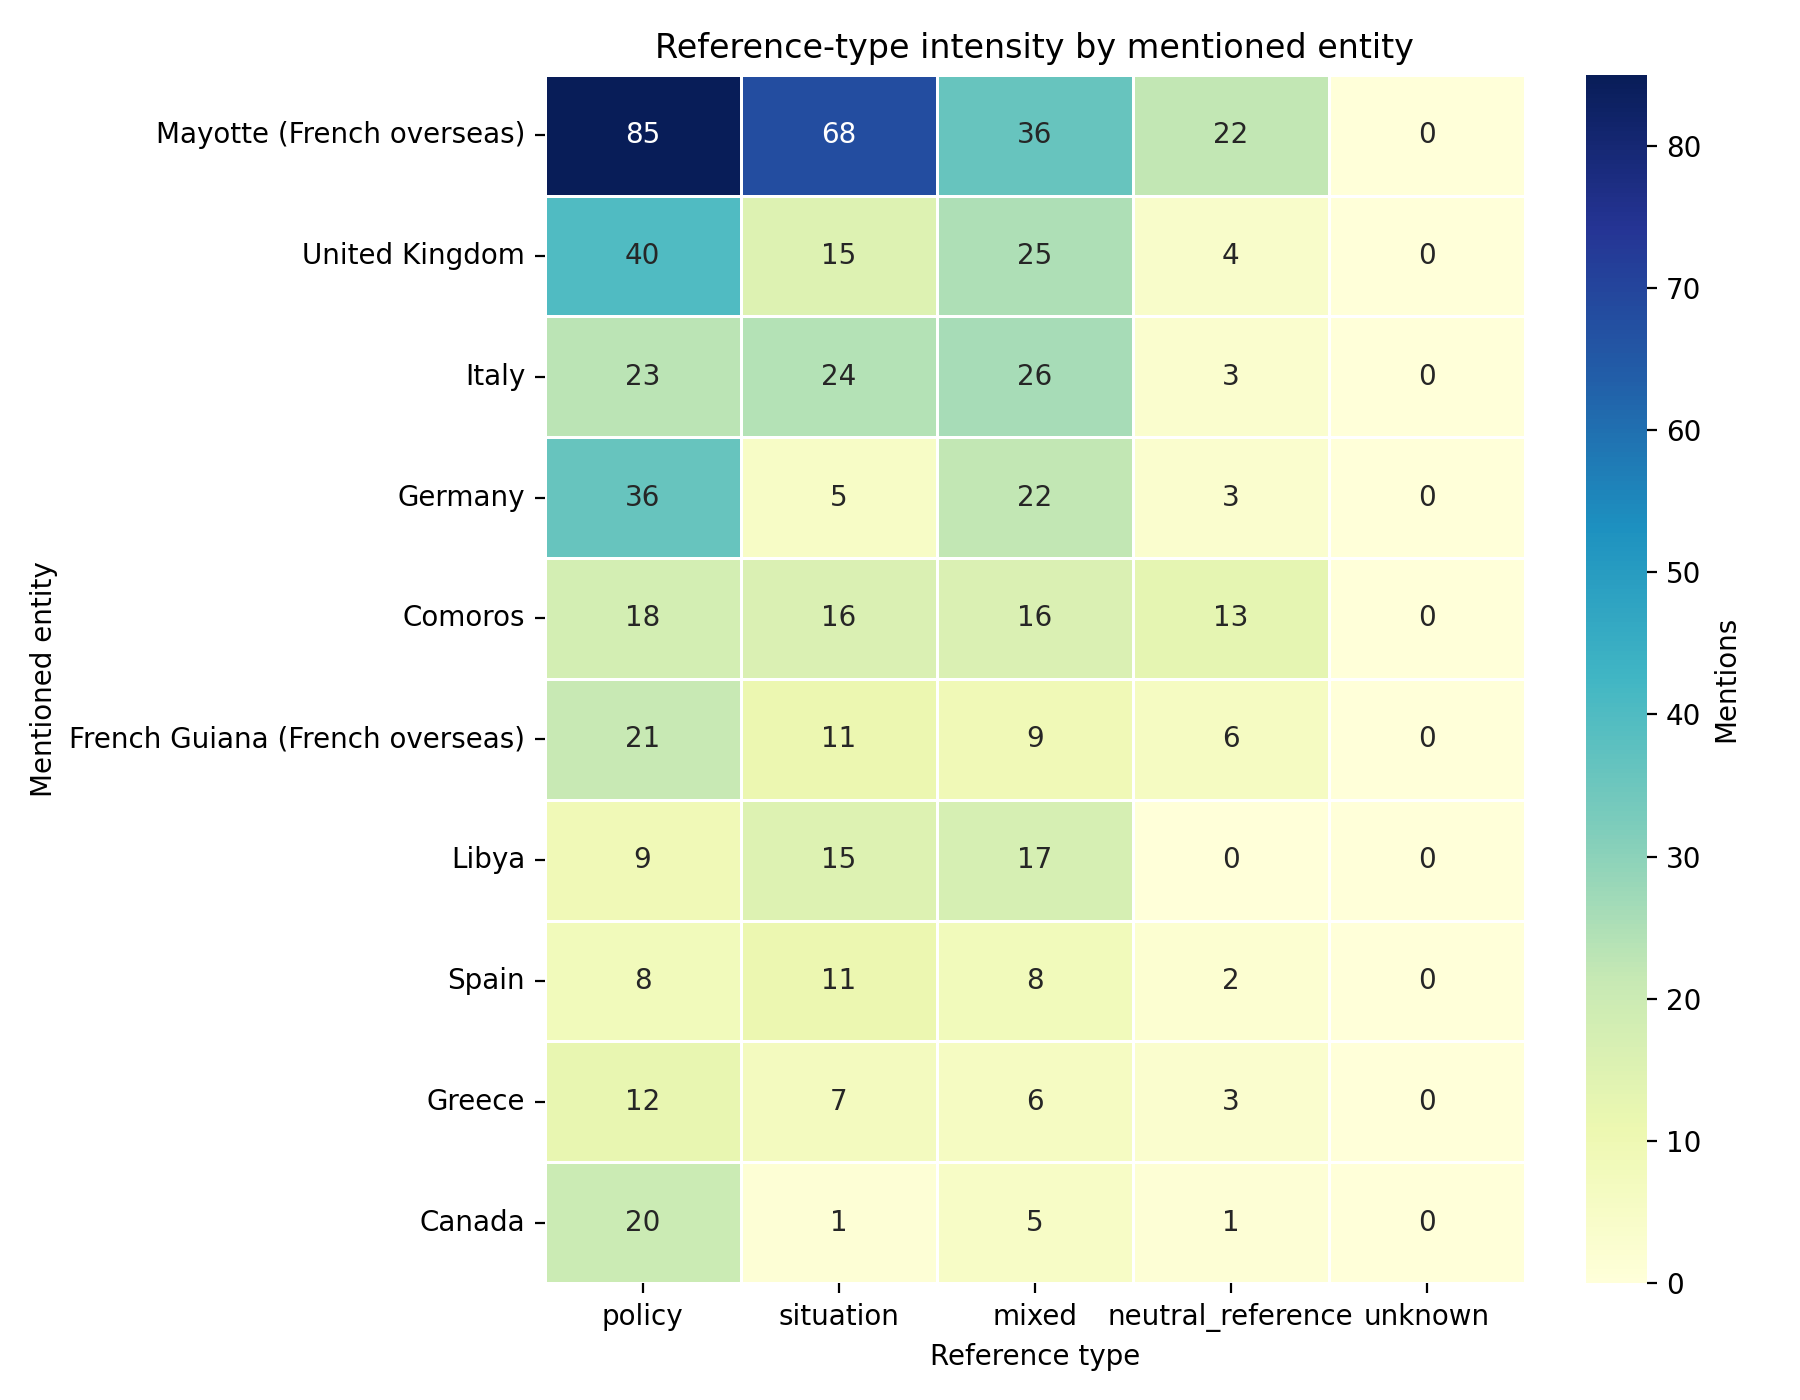

In [16]:
# Explanation: Display saved PNG figures inline and print non-image output paths.
for output_name, output_path in figure_paths.items():
    print(f"{output_name}: {output_path}")
    if str(output_path).endswith(".png"):
        display(Image(filename=str(output_path)))


In [17]:
# Explanation: Compact top-10 table for slides or notes.
# Explanation: The full displayed distribution above uses the >=50 mention threshold.
country_visual_summary = inspect.show_top_countries(annotated, top_n=10, min_mentions=5)
country_visual_summary


entity_content,n_mentions,geo_class,avg_sentiment,std_sentiment,min_sentiment,max_sentiment
str,u32,str,f32,f32,f32,f32
"""Mayotte""",211,"""french_overseas""",1.239,1.438,-0.111,5.075
"""United Kingdom""",84,"""foreign""",1.51,1.37,0.05,4.773
"""Italy""",76,"""foreign""",1.252,1.197,-0.077,4.817
"""Germany""",66,"""foreign""",1.499,1.264,0.07,4.835
"""Comoros""",63,"""foreign""",2.284,1.533,-0.027,4.975
"""French Guiana""",47,"""french_overseas""",1.484,1.254,0.013,4.229
"""Libya""",41,"""foreign""",1.213,1.371,-0.013,4.12
"""Spain""",29,"""foreign""",2.044,1.325,0.105,4.915
"""Greece""",28,"""foreign""",0.905,0.874,-0.027,2.8
